In [1]:
# for src folder access
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import os
import pandas as pd
from matplotlib import pyplot as plt

from src.config import TRIMMED_DATA_ROOT, ACTIVE_SECTIONS_DATA_ROOT, default_session_to_activity, Config
from src.preprocessing.clap_sync import accel_magnitude, simple_clap_sync

TRIMMED_DATA_ROOT

WindowsPath('C:/Users/blue_/Desktop/git-repos/HAR_Projekt/ax6_cnn_project/data/trimmed')

In [2]:
existing = [filename[:2] for filename in os.listdir(ACTIVE_SECTIONS_DATA_ROOT)]
filenames = [filename for filename in os.listdir(TRIMMED_DATA_ROOT) if filename[:2] not in existing]
remaining = [name[:2] for i, name in enumerate(filenames) if i % 2 != 1]
filenames

['22left.csv',
 '22right.csv',
 '23left.csv',
 '23right.csv',
 '24left.csv',
 '24right.csv',
 '25left.csv',
 '25right.csv',
 '26left.csv',
 '26right.csv',
 '27left.csv',
 '27right.csv',
 '28left.csv',
 '28right.csv',
 '29left.csv',
 '29right.csv',
 '30left.csv',
 '30right.csv',
 '31left.csv',
 '31right.csv']

### Example data

In [3]:
dfs = []
dfs_ = []
for filename in filenames:
    dfs_.append(pd.read_csv(os.path.join(TRIMMED_DATA_ROOT, filename)))
    if len(dfs_) == 2:
        dfs.append(dfs_)
        dfs_ = []

dfs[0][0]

,ax,ay,az,gx,gy,gz,acc_mag
0,-0.440430,-0.910645,0.004883,-1.716614,-2.136230,0.099182,1.011571
1,-0.441162,-0.908936,0.001709,-1.716614,-1.976013,0.297546,1.010342
2,-0.439453,-0.911133,0.000488,-1.625061,-1.777649,0.556946,1.011574
3,-0.440918,-0.912354,0.002686,-1.525879,-1.716614,0.633240,1.013314
4,-0.440430,-0.910156,0.000488,-1.426697,-1.884460,0.717163,1.011120
...,...,...,...,...,...,...,...
13445,-0.905273,0.616699,-0.053711,1.899719,-3.547668,-1.625061,1.096687
13446,-0.904297,0.620605,-0.059814,1.914978,-3.120422,-1.274109,1.098399
13447,-0.899902,0.619873,-0.065674,1.785278,-2.479553,-1.068115,1.094705
13448,-0.895508,0.622314,-0.067871,1.617432,-2.281189,-0.907898,1.092619


### Synchronisation

In [4]:
for dfL, dfR in dfs:
    dfL["acc_mag"] = accel_magnitude(dfL)
    dfR["acc_mag"] = accel_magnitude(dfR)
dfs_synced = [simple_clap_sync(dfL, dfR, search_samples=10*Config.fs)[:2] for dfL, dfR in dfs]

### First seconds

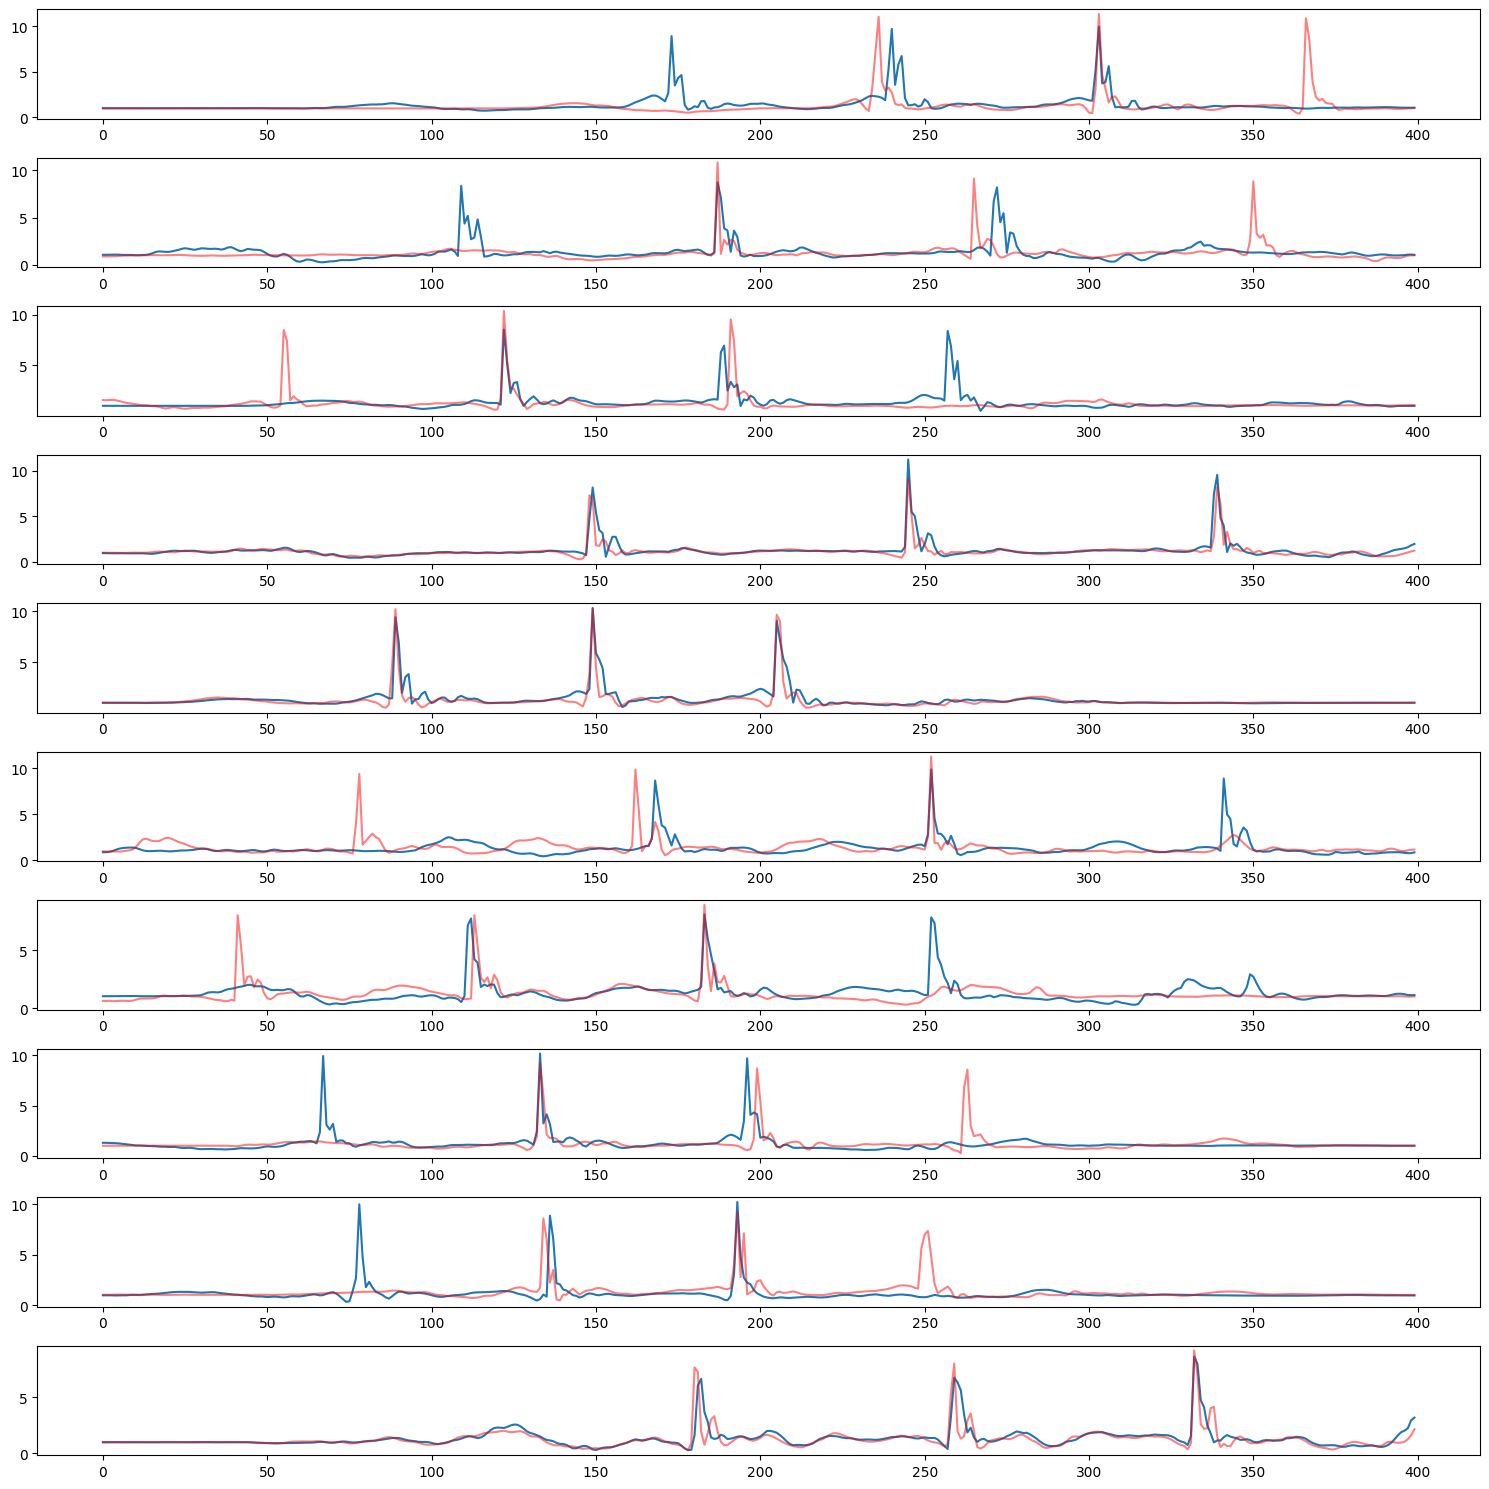

In [5]:
fig, ax = plt.subplots(10, 1, figsize=(15, 15))
for axis, (dfL, dfR) in zip(ax, dfs_synced):
    dfL["acc_mag"][:400].plot(ax=axis)
    dfR["acc_mag"][:400].plot(ax=axis, color="r", alpha=0.5)

plt.tight_layout()

In [6]:
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd

class FourLineCutter:
    def __init__(self, dfL, dfR, exercise_id):
        self.dfL = dfL
        self.dfR = dfR
        self.feature_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
        
        self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=(15, 2), sharex=True)
        
        # Hintergründe plotten
        self.ax1.plot(dfL.index, dfL["acc_mag"], color="royalblue", lw=1, label="Links")
        self.ax2.plot(dfR.index, dfR["acc_mag"], color="darkorange", lw=1, label="Rechts")
        
        self.ax1.set_title(f"High-Speed Cutting: {exercise_id}")
        self.ax1.legend()

        # Initiale Positionen
        idx = dfL.index
        pos = [idx[int(len(idx)*p)] for p in [0.1, 0.2, 0.7, 0.8]]
        
        self.lines = []
        self.active_line = None
        
        # 4 Linien-Paare erstellen (immer 2 pro Zeitpunkt: eine oben, eine unten)
        # Wir speichern sie als Paare, um sie später synchronisieren zu können
        colors = ['red', 'red', 'green', 'green']
        self.line_pairs = []
        
        for p, col in zip(pos, colors):
            l1 = self.ax1.axvline(p, color=col, lw=2, picker=10)
            l2 = self.ax2.axvline(p, color=col, lw=2, picker=10)
            self.line_pairs.append([l1, l2])
            self.lines.extend([l1, l2])

        # Event-Binding
        self.fig.canvas.mpl_connect('pick_event', self.on_pick)
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self.on_release)

        plt.tight_layout()
        
        # Blitting-Vorbereitung: Hintergrund speichern
        self.bg = None
        self.fig.canvas.draw()

    def on_pick(self, event):
        if event.artist in self.lines:
            self.active_line = event.artist
            # Den Hintergrund ohne die Linien "einfrieren" für flüssiges Ziehen
            # (In Jupyter/Widget manchmal schwierig, daher nutzen wir hier die simple Variante,
            # reduzieren aber die Redraw-Last)

    def on_motion(self, event):
        if self.active_line and event.xdata is not None:
            # Nur die aktuell gezogene Linie updaten
            self.active_line.set_xdata([event.xdata, event.xdata])
            # draw_idle ist effizienter als draw()
            self.fig.canvas.draw_idle() 

    def on_release(self, event):
        if self.active_line:
            curr_x = self.active_line.get_xdata()
            # Partner finden und nachziehen (nach dem Loslassen)
            for pair in self.line_pairs:
                if self.active_line in pair:
                    pair[0].set_xdata(curr_x)
                    pair[1].set_xdata(curr_x)
            
            self.active_line = None
            self.fig.canvas.draw_idle()

    def get_data(self):
        # Positionen extrahieren
        x_red = sorted([self.line_pairs[0][0].get_xdata()[0], self.line_pairs[1][0].get_xdata()[0]])
        x_green = sorted([self.line_pairs[2][0].get_xdata()[0], self.line_pairs[3][0].get_xdata()[0]])
        
        def cut(range_x):
            s, e = range_x
            # Nutze .loc für schnelles Slicing
            cL = self.dfL.loc[s:e, self.feature_cols]
            cR = self.dfR.loc[s:e, self.feature_cols]
            combined = pd.concat([cL, cR], axis=1, join='inner')
            return combined

        return cut(x_red), cut(x_green)


### Manual extraction

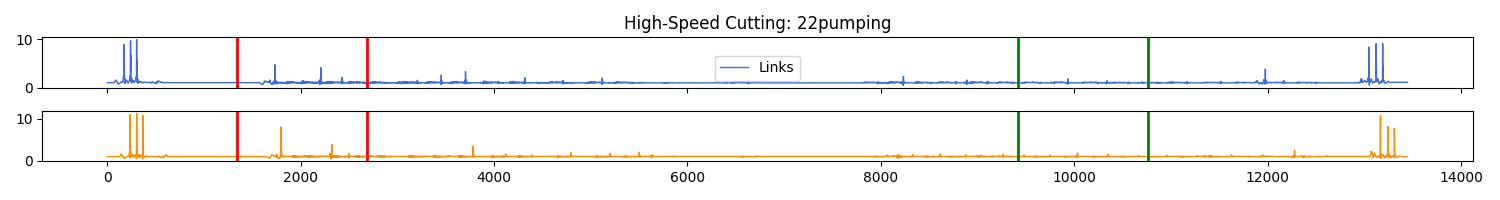

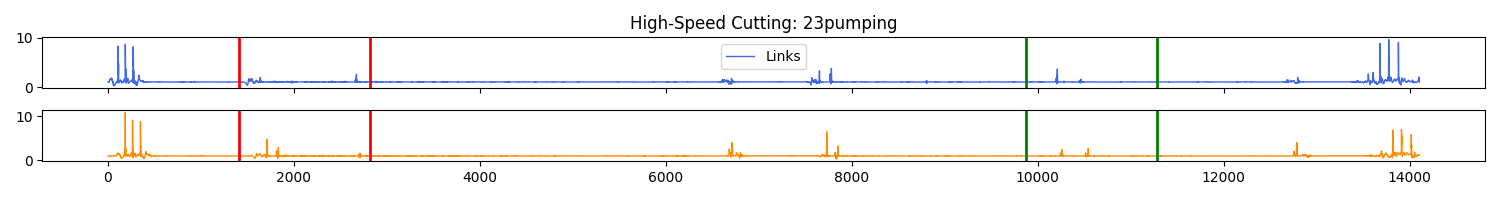

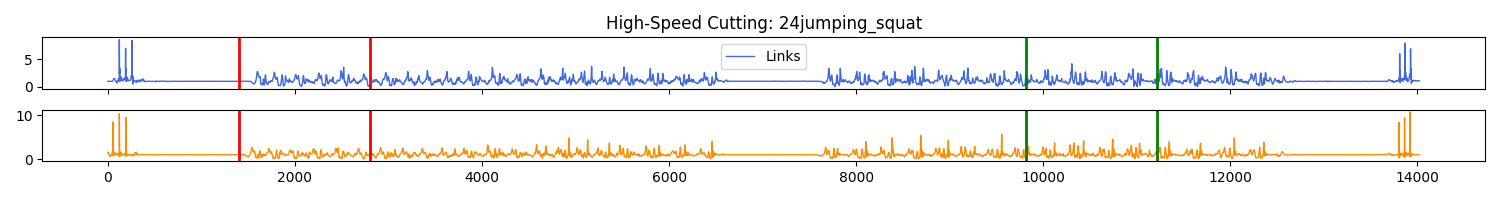

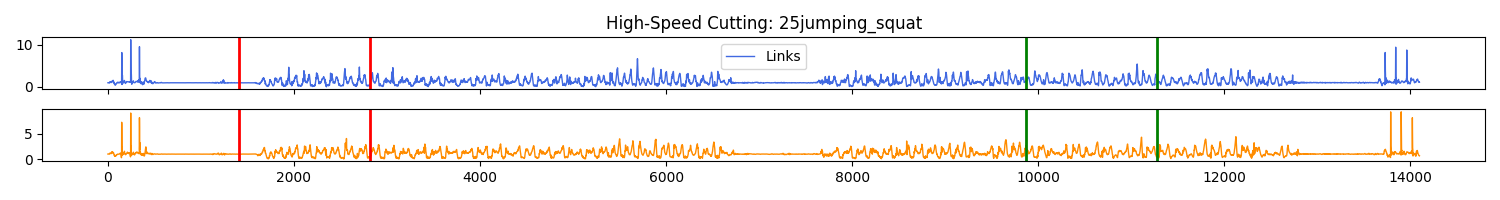

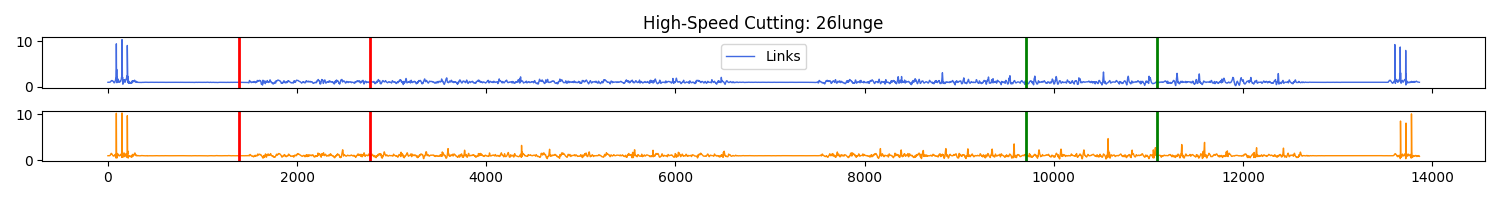

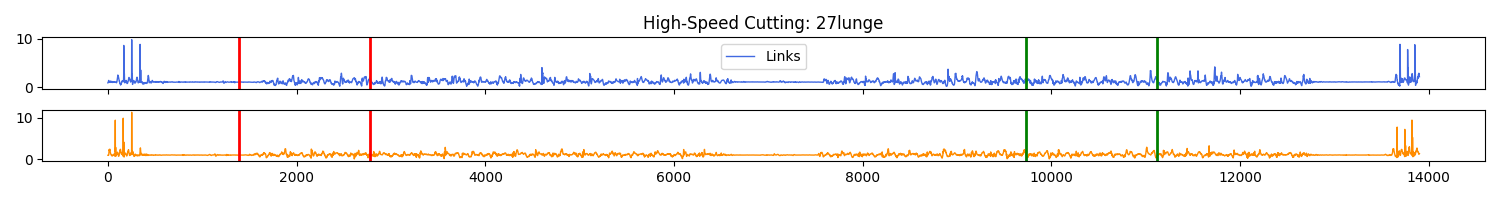

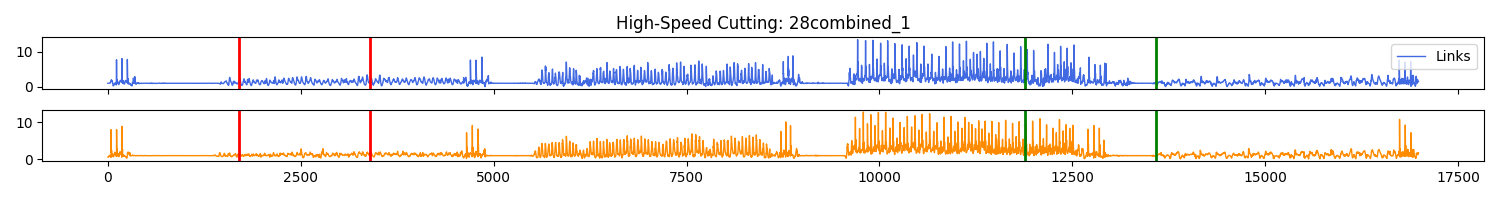

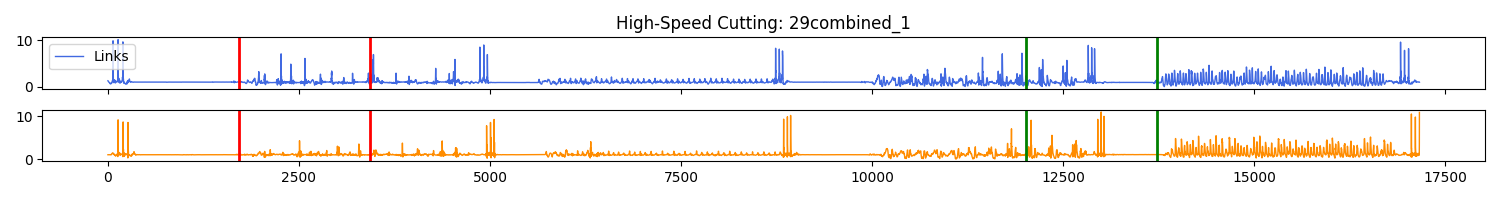

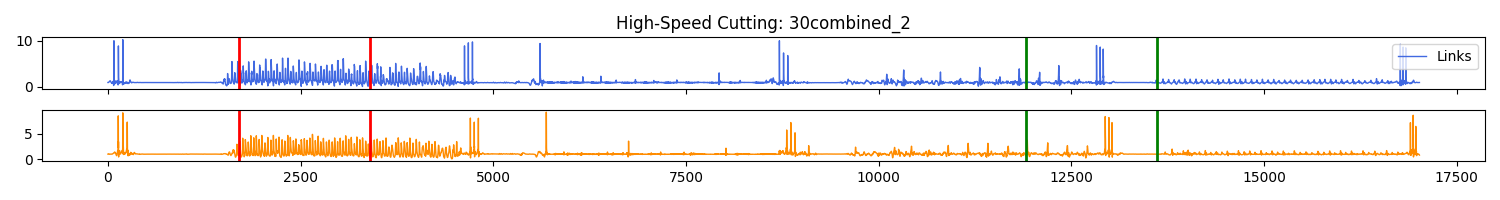

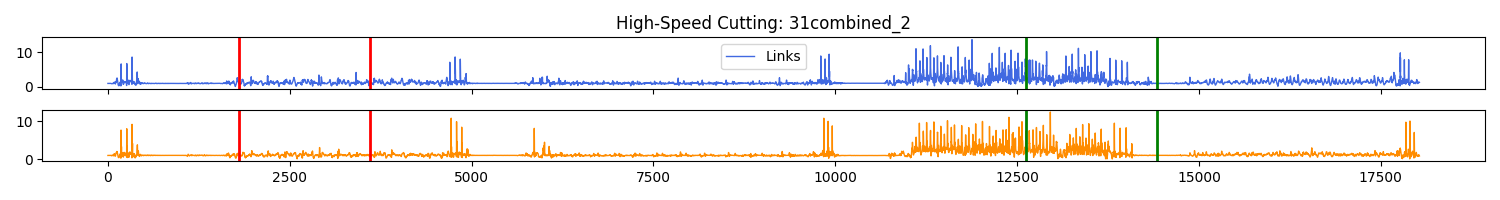

In [10]:
cutters = [FourLineCutter(dfL, dfR, id+default_session_to_activity()[str(id)]) for id, (dfL, dfR) in zip(remaining, dfs_synced)]

In [8]:
tensors = [c.get_data() for c in cutters]

### Save the files

In [9]:
if not os.path.exists(ACTIVE_SECTIONS_DATA_ROOT):
    os.mkdir(ACTIVE_SECTIONS_DATA_ROOT)
    
for (t1, t2), id in zip(tensors, range(12, 22)):
    _path = os.path.join(ACTIVE_SECTIONS_DATA_ROOT, str(id))
    if _path + "part1.csv" not in os.listdir(ACTIVE_SECTIONS_DATA_ROOT):
        t1.to_csv(_path + "part1.csv", index=False)
        t2.to_csv(_path + "part2.csv", index=False)